In [1]:
import pandas as pd
# import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt


In [2]:
df=pd.read_table('Fig1c.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
0,8241,Liarum,Sweden,55.9473,13.8210,CS77038,leaf,Sweden_leaf,6425.217028,6.800000,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6203,TDr-18,Sweden,55.7714,14.1208,CS77350,leaf,Sweden_leaf,6106.090545,7.400000,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5984,DraIV 6-13,Czech Republic,49.4112,16.2815,CS76822,leaf,Czech Republic_leaf,5937.667641,7.395833,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,9399,Hamm-1,Sweden,55.4234,13.9905,CS76910,leaf,Sweden_leaf,5936.194976,7.937500,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,8420,Kelsterbach-4,GER,50.0667,8.5333,CS76525,leaf,GER_leaf,5842.619693,10.337500,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [3]:
df=df.rename(columns={'coarse_frag':'coarse frag',
                   'bulk_density':'bulk density',
                   'CaCO3':'CaCO$_3$',
                     'ph':'pH',
                     'ai':'AI',
                     'awc':'AWC'})

In [4]:
df=df.select_dtypes(include='number')
df=df.drop(columns=['Accession_ID','Latitude','Longitude'])
df.head()

,Mg25,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
0,6425.217028,6.800000,7.100000,29.831934,632.671082,20.400000,-3.4,23.799999,3.716667,5.483333,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6106.090545,7.400000,6.966667,29.645391,620.901123,21.000000,-2.5,23.500000,4.400000,2.383333,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5937.667641,7.395833,8.241667,30.079075,733.808411,22.500000,-4.9,27.400000,16.350000,-0.300000,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,5936.194976,7.937500,6.741666,28.566383,631.276184,21.299999,-2.3,23.599998,8.766666,2.783333,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,5842.619693,10.337500,8.458333,32.532051,672.647827,25.100000,-0.9,26.000000,17.166666,6.133333,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [8]:
df['Ca/Mg']=df['CaCO$_3$']/df['Mg']

In [9]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)


In [11]:
df.shape

(677, 40)

# Random_state = 1

## With all variables

In [12]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)


In [14]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 4, 'max_leaf_nodes': 6, 'n_estimators': 200}
0.1861365100584694


In [15]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 300.15
Mean Squared Error: 146743.85
R-squared scores: 0.22


In [16]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

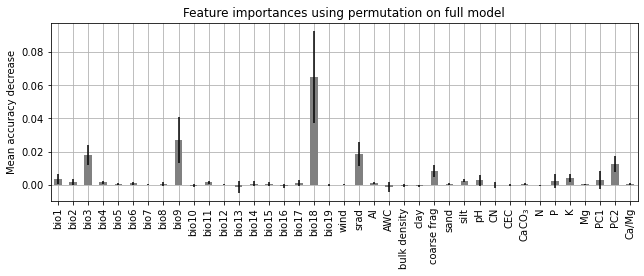

In [17]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# With the most important variables

In [182]:
X_train=X_train[['bio3','bio9','bio18','srad','PC2']]
X_test=X_test[['bio3','bio9','bio18','srad','PC2']]

In [184]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 4, 'max_leaf_nodes': 5, 'n_estimators': 200}
0.1922715867897458


In [185]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 299.82
Mean Squared Error: 142897.23
R-squared scores: 0.24


In [186]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

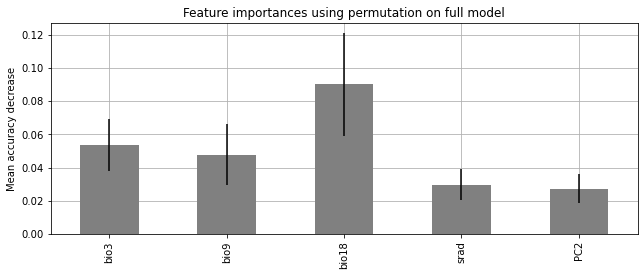

In [187]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# Without variables combining precipitation and temperature

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)
X_train=X_train.drop(columns=['bio8','bio9','bio18','bio19'])
X_test=X_test.drop(columns=['bio8','bio9','bio18','bio19'])

In [191]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 6, 'max_leaf_nodes': 7, 'n_estimators': 200}
0.18441946940790568


In [193]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 298.66
Mean Squared Error: 146223.72
R-squared scores: 0.22


In [194]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

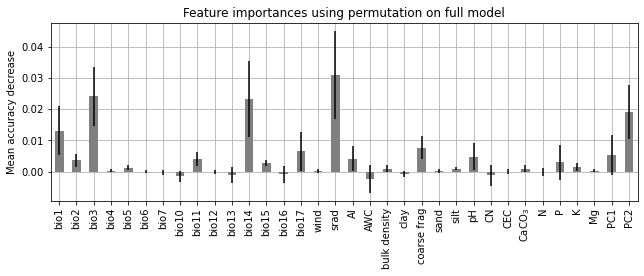

In [195]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

## Random_state = 0

In [196]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

In [197]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)


In [198]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 3, 'max_leaf_nodes': 4, 'n_estimators': 200}
0.17174904119468246


In [199]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 306.91
Mean Squared Error: 146064.36
R-squared scores: 0.21


In [200]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

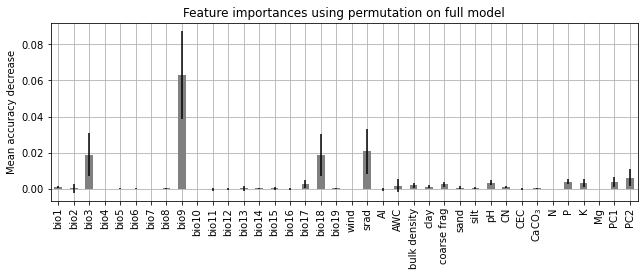

In [201]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# With the most important variables

In [202]:
X_train=X_train[['bio3','bio9','bio18','srad','PC2']]
X_test=X_test[['bio3','bio9','bio18','srad','PC2']]

In [203]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 3, 'max_leaf_nodes': 5, 'n_estimators': 200}
0.1776157746394726


In [204]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 307.1
Mean Squared Error: 145130.22
R-squared scores: 0.22


In [205]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

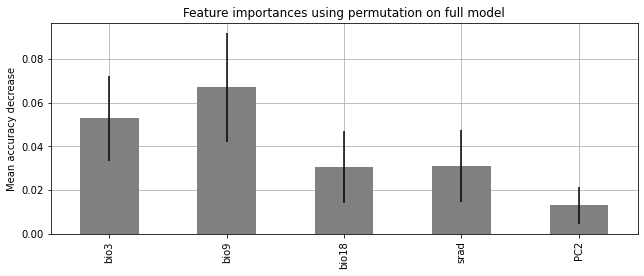

In [206]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# Without variables combining precipitation and temperature

In [207]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
X_train=X_train.drop(columns=['bio8','bio9','bio18','bio19'])
X_test=X_test.drop(columns=['bio8','bio9','bio18','bio19'])

In [208]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 3, 'max_leaf_nodes': 4, 'n_estimators': 200}
0.15881172821568745


In [209]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 308.59
Mean Squared Error: 146819.04
R-squared scores: 0.21


In [210]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

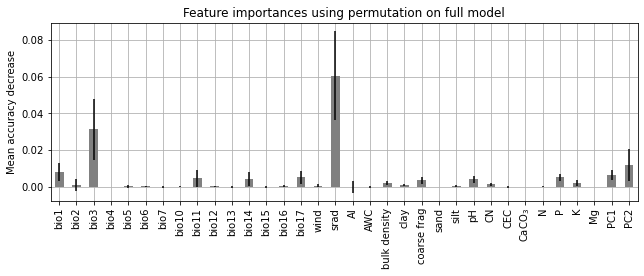

In [211]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

## Random_state = 42

In [212]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

In [213]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [214]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 3, 'max_leaf_nodes': 4, 'n_estimators': 100}
0.20542805521095778


In [215]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 320.27
Mean Squared Error: 162014.09
R-squared scores: 0.14


In [216]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

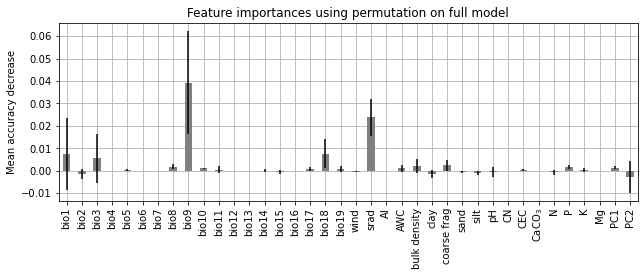

In [217]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# With the most important variables

In [218]:
X_train=X_train[['bio3','bio9','bio18','srad','PC2']]
X_test=X_test[['bio3','bio9','bio18','srad','PC2']]

In [219]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 3, 'max_leaf_nodes': 5, 'n_estimators': 200}
0.22019899769772014


In [220]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 317.45
Mean Squared Error: 161024.79
R-squared scores: 0.14


In [221]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

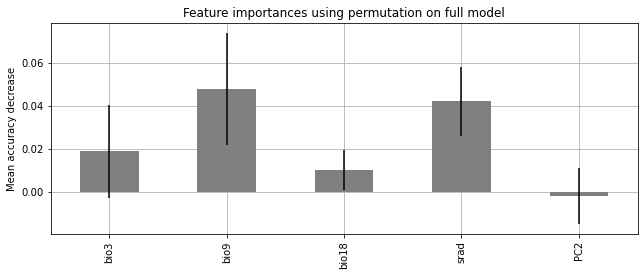

In [222]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# Without variables combining precipitation and temperature

In [223]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train=X_train.drop(columns=['bio8','bio9','bio18','bio19'])
X_test=X_test.drop(columns=['bio8','bio9','bio18','bio19'])

In [224]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 3, 'max_leaf_nodes': 4, 'n_estimators': 200}
0.197440190579606


In [225]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 325.13
Mean Squared Error: 165106.12
R-squared scores: 0.12


In [226]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

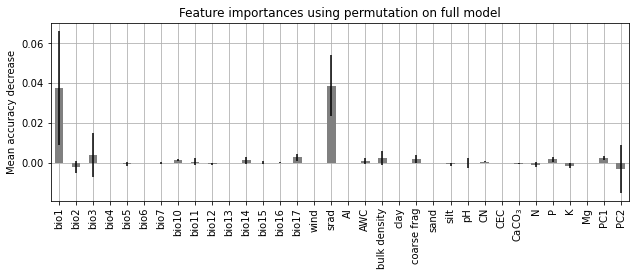

In [227]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# Adding Top SNP from GWAS

In [130]:
df2=pd.read_table('Fig1c_test.txt')
df2.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,Mg,PC1,PC2,S470fs,top_peak,splice,N715A,Chr5_21390834,Chr5_21392702,Chr5_282011
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,4513.790113,11.829166,...,38,-0.024919,0.024124,0,0,0,1,0.0,0.0,1.0
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,4444.244161,11.100000,...,31,-0.017065,0.018734,0,0,0,1,0.0,0.0,1.0
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,4548.751871,11.100000,...,31,-0.018403,0.018840,0,0,0,1,0.0,0.0,1.0
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,4808.545837,9.325000,...,29,-0.029610,0.022555,0,0,0,1,0.0,0.0,1.0
4,350,TOU-A1-88,France,46.6667,4.116670,CS77382,leaf,France_leaf,5189.422620,10.720833,...,36,-0.029266,0.026182,0,0,0,1,0.0,0.0,1.0


In [131]:
df2=df2.rename(columns={'coarse_frag':'coarse frag',
                   'bulk_density':'bulk density',
                   'CaCO3':'CaCO$_3$',
                     'ph':'pH',
                     'ai':'AI',
                     'awc':'AWC'})

In [132]:
df2.shape

(677, 54)

In [133]:
df2=df2.dropna()
df2.shape

(552, 54)

In [134]:
df2=df2.select_dtypes(include='number')
df2=df2.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A'])
df2.head()

,Mg25,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,...,CaCO$_3$,N,P,K,Mg,PC1,PC2,Chr5_21390834,Chr5_21392702,Chr5_282011
0,4513.790113,11.829166,8.825000,37.875538,557.541077,25.500000,2.2,23.299999,6.050000,18.916666,...,56.835339,1.240112,36.844051,226.204865,38,-0.024919,0.024124,0.0,0.0,1.0
1,4444.244161,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,17.000000,7.566667,15.983334,...,38.288258,2.772524,44.490234,201.766663,31,-0.017065,0.018734,0.0,0.0,1.0
2,4548.751871,11.100000,6.416667,37.745098,392.538361,20.799999,3.8,17.000000,7.566667,15.983334,...,38.288258,2.772524,44.490234,201.766663,31,-0.018403,0.018840,0.0,0.0,1.0
3,4808.545837,9.325000,7.700000,32.352940,596.430664,22.700001,-1.1,23.800001,3.216667,5.133333,...,25.146477,2.195257,25.737415,143.398697,29,-0.029610,0.022555,0.0,0.0,1.0
4,5189.422620,10.720833,9.175000,35.562016,621.583252,25.400000,-0.4,25.799999,16.683332,6.666667,...,0.782203,1.743629,36.619621,237.669601,36,-0.029266,0.026182,0.0,0.0,1.0


In [135]:
df2.shape

(552, 42)

In [136]:
X=df2.drop(columns=['Mg25'])
y=df2['Mg25']

In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [138]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 1)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 6, 'max_leaf_nodes': 9, 'n_estimators': 100}
0.2734053505819163


In [139]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 284.88
Mean Squared Error: 129497.18
R-squared scores: 0.33


In [140]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=1, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

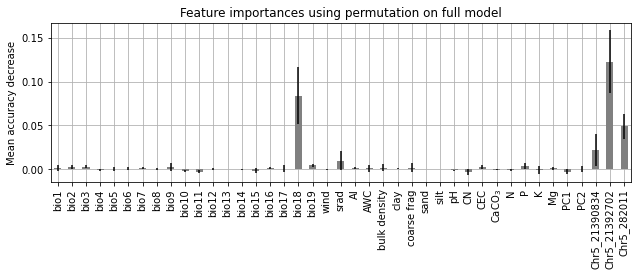

In [141]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [142]:
df2_filtered=df2[['Mg25','bio9','bio18','srad','AWC','Chr5_21390834','Chr5_21392702','Chr5_282011']]
df2_filtered.head()

,Mg25,bio9,bio18,srad,AWC,Chr5_21390834,Chr5_21392702,Chr5_282011
0,4513.790113,18.916666,134,11783.83301,0.081047,0.0,0.0,1.0
1,4444.244161,15.983334,193,11146.58301,0.091235,0.0,0.0,1.0
2,4548.751871,15.983334,193,11146.58301,0.091235,0.0,0.0,1.0
3,4808.545837,5.133333,213,11838.91699,0.102306,0.0,0.0,1.0
4,5189.422620,6.666667,217,12031.58301,0.103813,0.0,0.0,1.0


In [143]:
X=df2_filtered.drop(columns=['Mg25'])
y=df2_filtered['Mg25']

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [145]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[50,100,200]}
forest_model= RandomForestRegressor(random_state = 1)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 6, 'max_leaf_nodes': 9, 'n_estimators': 200}
0.30264819133203286


In [146]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 3))

Mean Absolute Error: 282.27
Mean Squared Error: 127232.74
R-squared scores: 0.346


In [147]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=1, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

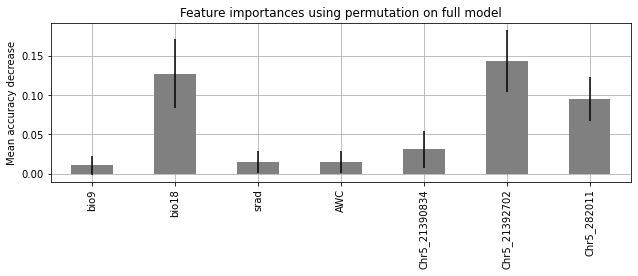

In [148]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# With stratification

In [292]:
df=df[df.duplicated(subset=['Country'],keep=False)]

In [293]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

In [317]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42,stratify=X['Country'])

In [318]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
287,10.170834,7.791667,38.008129,472.076935,22.000000,1.5,20.500000,7.750000,6.483333,16.266666,...,5.772104,13.715875,13.949490,0.000000,2.615070,26.493233,188.694763,31,-0.018588,0.031255
56,11.250000,9.366667,31.537598,767.673584,27.000000,-2.7,29.700001,16.600000,1.733333,20.616667,...,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.019555,-0.014141
663,16.216667,7.050000,31.756756,558.245361,28.600000,6.4,22.200001,14.266666,23.100000,23.350000,...,6.880644,10.763082,15.530464,83.813835,1.907678,20.237658,351.257385,24,-0.022566,0.022191
45,11.250000,9.366667,31.537598,767.673584,27.000000,-2.7,29.700001,16.600000,1.733333,20.616667,...,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.020433,-0.013291
47,9.162500,9.158334,32.708332,712.489624,24.200001,-3.8,28.000000,18.016666,0.583333,18.016666,...,6.397152,13.569145,20.028221,61.336304,1.893738,16.866127,198.365829,52,-0.022620,-0.004213


In [319]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
665,9.137500,8.541667,32.354797,653.845703,24.5,-1.9,26.400000,5.616667,17.733334,17.733334,...,6.508832,11.860096,14.233815,55.321808,1.747500,25.260445,107.610245,61,0.118787,0.045686
228,9.162500,10.725000,38.579136,609.873779,25.1,-2.7,27.800001,6.233333,2.966667,17.200001,...,6.392577,14.800039,20.528246,49.911823,3.750896,11.483948,216.613678,48,0.082162,0.031614
49,8.941667,6.766666,31.039755,577.182922,21.1,-0.7,21.800001,16.100000,4.600000,16.100000,...,6.241703,10.743577,19.869848,0.692850,3.875818,64.735283,137.428818,48,0.007429,-0.017109
375,11.250000,9.366667,31.537598,767.673584,27.0,-2.7,29.700001,16.600000,1.733333,20.616667,...,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.013151,-0.009219
319,8.470834,8.708333,33.493591,656.614807,22.9,-3.1,26.000000,15.033333,1.650000,16.666666,...,6.613173,11.282214,27.255800,84.860046,2.696891,24.213699,206.133362,47,-0.035502,0.004888


In [324]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 6, 'max_leaf_nodes': 9, 'n_estimators': 200}
0.17382063769688247


In [325]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 312.92
Mean Squared Error: 159980.85
R-squared scores: 0.25


In [326]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

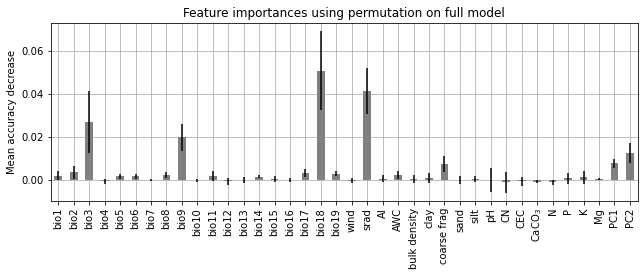

In [327]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# With the most important variables

In [328]:
X_train=X_train[['bio3','bio9','bio18','srad','PC2']]
X_test=X_test[['bio3','bio9','bio18','srad','PC2']]

In [329]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 5, 'max_leaf_nodes': 9, 'n_estimators': 100}
0.16485544650692835


In [330]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 303.16
Mean Squared Error: 151868.86
R-squared scores: 0.29


In [331]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

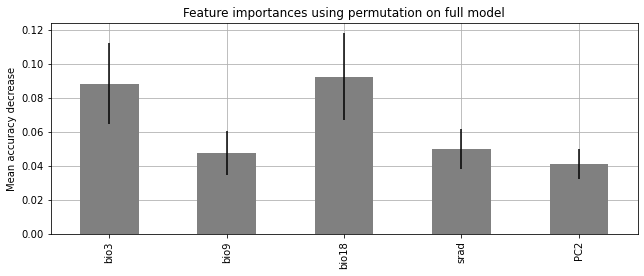

In [332]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# Without variables combining precipitation and temperature

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)
X_train=X_train.drop(columns=['bio8','bio9','bio18','bio19'])
X_test=X_test.drop(columns=['bio8','bio9','bio18','bio19'])

In [191]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 6, 'max_leaf_nodes': 7, 'n_estimators': 200}
0.18441946940790568


In [193]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 298.66
Mean Squared Error: 146223.72
R-squared scores: 0.22


In [194]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

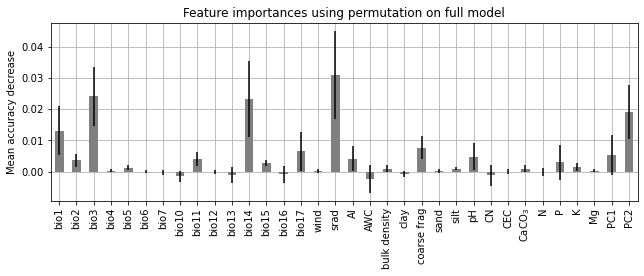

In [195]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# With the top 3 SNPs from the GWAS

In [393]:
df2=pd.read_table('Fig1c_test.txt')
df2.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,Mg,PC1,PC2,S470fs,top_peak,splice,N715A,Chr5_21390834,Chr5_21392702,Chr5_282011
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,4513.790113,11.829166,...,38,-0.024919,0.024124,0,0,0,1,0.0,0.0,1.0
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,4444.244161,11.100000,...,31,-0.017065,0.018734,0,0,0,1,0.0,0.0,1.0
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,4548.751871,11.100000,...,31,-0.018403,0.018840,0,0,0,1,0.0,0.0,1.0
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,4808.545837,9.325000,...,29,-0.029610,0.022555,0,0,0,1,0.0,0.0,1.0
4,350,TOU-A1-88,France,46.6667,4.116670,CS77382,leaf,France_leaf,5189.422620,10.720833,...,36,-0.029266,0.026182,0,0,0,1,0.0,0.0,1.0


In [394]:
df2.shape

(677, 54)

In [396]:
df2=df2.dropna()

In [397]:
df2=df2[df2.duplicated(subset=['Country'],keep=False)]

In [398]:
X=df2.drop(columns=['Mg25'])
y=df2['Mg25']

In [399]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0,stratify=X['Country'])

In [400]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A','Chr5_21390834','Chr5_21392702','Chr5_282011'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
619,10.158334,7.583333,34.159161,547.119873,22.9,0.7,22.199999,7.133333,6.216667,16.983334,...,6.203156,11.780995,7.645063,1.362831,1.860576,46.690781,205.509262,37,-0.008169,0.015554
283,10.079166,8.125000,31.988190,661.422241,24.4,-1.0,25.400000,16.783333,3.250000,18.383333,...,5.900896,15.060525,4.649007,38.131313,1.570979,23.699923,141.818512,42,-0.037216,-0.001287
473,12.004167,10.725000,33.939873,775.430847,29.0,-2.6,31.600000,7.700000,20.950001,21.549999,...,6.778843,12.814929,27.501640,72.673447,1.338050,19.887054,249.277084,40,0.002278,0.011588
98,7.820833,6.758333,28.758865,642.680664,21.0,-2.5,23.500000,4.750000,2.666667,15.966666,...,5.713981,14.544075,9.685768,2.897898,2.495770,38.483131,89.823921,36,-0.019560,-0.040287
461,11.250000,9.366667,31.537598,767.673584,27.0,-2.7,29.700001,16.600000,1.733333,20.616667,...,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.020131,-0.015884


In [401]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A','Chr5_21390834','Chr5_21392702','Chr5_282011'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
270,9.950000,7.700000,37.745098,475.461517,21.600000,1.2,20.400000,5.466667,14.300000,16.000000,...,6.318985,10.549542,12.843287,17.212914,3.450265,39.596661,211.670746,34,-0.028628,0.002165
407,12.708333,8.316667,41.792294,433.583557,23.100000,3.2,19.900000,10.566667,18.083334,18.283333,...,5.788593,9.745921,13.185417,0.000000,2.819362,37.183872,268.577087,41,0.009936,0.011404
513,8.375000,9.400000,35.074627,659.853638,23.500000,-3.3,26.799999,14.916667,1.516667,16.633333,...,6.428132,9.122652,12.113892,0.000000,2.160906,40.403454,220.521973,46,-0.034134,0.009626
545,11.633333,11.900000,40.202702,632.427978,29.000000,-0.6,29.600000,7.883333,19.633333,19.816666,...,6.823444,13.519884,6.780015,35.766224,0.961916,13.741580,154.928467,55,0.035880,0.049226
294,8.904166,7.875000,31.882591,643.906616,22.799999,-1.9,24.699999,15.466666,4.733333,17.000000,...,6.799488,9.878675,14.539287,4.578620,1.903177,48.942635,256.557770,47,-0.032175,-0.006864


In [402]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 5, 'max_leaf_nodes': 8, 'n_estimators': 100}
0.19226037379096636


In [379]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 324.35
Mean Squared Error: 164035.04
R-squared scores: 0.23


In [403]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

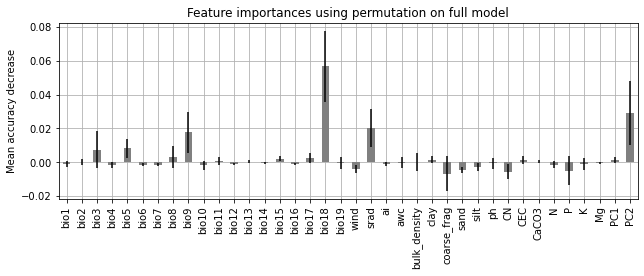

In [404]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# With the most important variables

In [380]:
X_train=X_train[['bio3','bio9','bio18','srad','PC2']]
X_test=X_test[['bio3','bio9','bio18','srad','PC2']]

In [368]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 4, 'max_leaf_nodes': 7, 'n_estimators': 200}
0.1793599865124813


In [369]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 322.08
Mean Squared Error: 156876.18
R-squared scores: 0.26


In [370]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

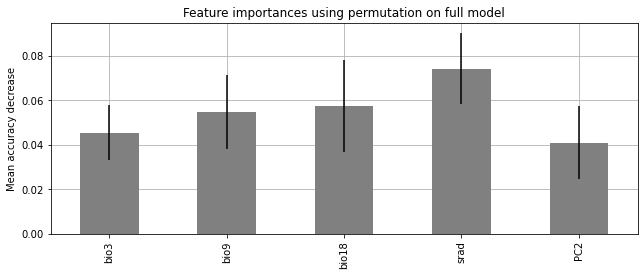

In [371]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# Without variables combining precipitation and temperature

In [382]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0,stratify=X['Country'])


In [383]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A','Chr5_21390834','Chr5_21392702','Chr5_282011','bio8','bio9','bio18','bio19'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio10,bio11,bio12,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
381,12.595834,11.558333,40.555557,604.808228,29.000000,0.5,28.500000,20.333334,5.616667,598,...,7.295624,7.874639,11.773749,38.761192,1.512748,29.668633,219.893326,47,0.018583,0.033407
301,3.629167,7.491666,25.922722,762.541992,19.400000,-9.5,28.900000,13.650000,-5.100000,719,...,4.512662,23.880318,10.086387,4.951549,2.901053,30.837130,168.004746,37,0.096012,-0.133015
110,3.191667,7.950000,26.411959,801.920532,19.500000,-10.6,30.100000,13.550000,-6.300000,729,...,4.223059,21.625450,13.204588,10.963806,3.857980,32.582630,175.875122,28,0.039146,-0.065792
534,8.766666,8.866667,33.713562,665.590393,23.400000,-2.9,26.299999,17.066666,0.716667,742,...,6.701809,11.091600,23.283407,55.877907,2.742160,33.521145,235.390961,45,-0.029492,0.005220
269,8.116667,6.600000,28.205130,644.262573,21.299999,-2.1,23.400000,16.266666,0.600000,632,...,6.158042,13.136587,13.259787,0.000000,1.649587,51.949928,141.778809,34,-0.016212,-0.039076


In [384]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A','Chr5_21390834','Chr5_21392702','Chr5_282011','bio8','bio9','bio18','bio19'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio10,bio11,bio12,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
481,12.079166,10.775000,33.883648,779.065430,29.299999,-2.5,31.799999,21.700001,2.616667,591,...,7.217086,14.112103,24.702406,52.634716,1.549563,12.414071,260.405792,44,-0.008321,0.007267
386,9.600000,13.483334,42.004154,658.196594,28.500000,-3.6,32.099998,18.283333,2.316667,535,...,7.311369,12.574229,21.109697,218.790741,1.506888,26.133642,151.906921,35,0.077234,0.038065
408,11.025000,10.233334,41.263439,533.766602,25.500000,0.7,24.799999,17.950001,5.000000,777,...,6.409295,14.024984,15.261152,138.900772,3.707595,17.586332,173.479095,35,0.008564,0.025612
176,7.212500,7.408333,30.868055,627.401306,21.100000,-2.9,24.000000,15.233334,-0.083333,679,...,5.355847,14.095119,14.888178,9.826324,2.449366,44.616016,113.077187,35,-0.003314,-0.011153
456,11.250000,9.366667,31.537598,767.673584,27.000000,-2.7,29.700001,20.616667,1.733333,828,...,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.014822,-0.012225


In [385]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 6, 'max_leaf_nodes': 7, 'n_estimators': 200}
0.18285274638104335


In [386]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 330.35
Mean Squared Error: 167905.75
R-squared scores: 0.21


In [387]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

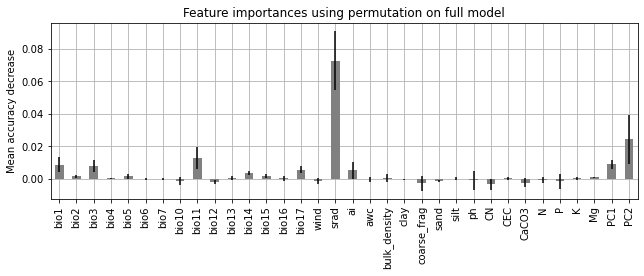

In [388]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# With top 3 SNPs

In [405]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0,stratify=X['Country'])

In [406]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,CaCO3,N,P,K,Mg,PC1,PC2,Chr5_21390834,Chr5_21392702,Chr5_282011
619,10.158334,7.583333,34.159161,547.119873,22.9,0.7,22.199999,7.133333,6.216667,16.983334,...,1.362831,1.860576,46.690781,205.509262,37,-0.008169,0.015554,0.0,0.0,1.0
283,10.079166,8.125000,31.988190,661.422241,24.4,-1.0,25.400000,16.783333,3.250000,18.383333,...,38.131313,1.570979,23.699923,141.818512,42,-0.037216,-0.001287,0.0,0.0,1.0
473,12.004167,10.725000,33.939873,775.430847,29.0,-2.6,31.600000,7.700000,20.950001,21.549999,...,72.673447,1.338050,19.887054,249.277084,40,0.002278,0.011588,0.0,0.0,1.0
98,7.820833,6.758333,28.758865,642.680664,21.0,-2.5,23.500000,4.750000,2.666667,15.966666,...,2.897898,2.495770,38.483131,89.823921,36,-0.019560,-0.040287,0.0,0.0,1.0
461,11.250000,9.366667,31.537598,767.673584,27.0,-2.7,29.700001,16.600000,1.733333,20.616667,...,105.279900,1.976948,30.124363,168.221390,52,-0.020131,-0.015884,0.0,0.0,1.0


In [407]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,CaCO3,N,P,K,Mg,PC1,PC2,Chr5_21390834,Chr5_21392702,Chr5_282011
270,9.950000,7.700000,37.745098,475.461517,21.600000,1.2,20.400000,5.466667,14.300000,16.000000,...,17.212914,3.450265,39.596661,211.670746,34,-0.028628,0.002165,0.0,0.0,0.0
407,12.708333,8.316667,41.792294,433.583557,23.100000,3.2,19.900000,10.566667,18.083334,18.283333,...,0.000000,2.819362,37.183872,268.577087,41,0.009936,0.011404,1.0,0.0,1.0
513,8.375000,9.400000,35.074627,659.853638,23.500000,-3.3,26.799999,14.916667,1.516667,16.633333,...,0.000000,2.160906,40.403454,220.521973,46,-0.034134,0.009626,0.0,0.0,1.0
545,11.633333,11.900000,40.202702,632.427978,29.000000,-0.6,29.600000,7.883333,19.633333,19.816666,...,35.766224,0.961916,13.741580,154.928467,55,0.035880,0.049226,0.0,0.0,1.0
294,8.904166,7.875000,31.882591,643.906616,22.799999,-1.9,24.699999,15.466666,4.733333,17.000000,...,4.578620,1.903177,48.942635,256.557770,47,-0.032175,-0.006864,0.0,0.0,1.0


In [408]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 1)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 5, 'max_leaf_nodes': 8, 'n_estimators': 200}
0.28381614336010075


In [409]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 263.84
Mean Squared Error: 114049.95
R-squared scores: 0.33


In [410]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=1, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

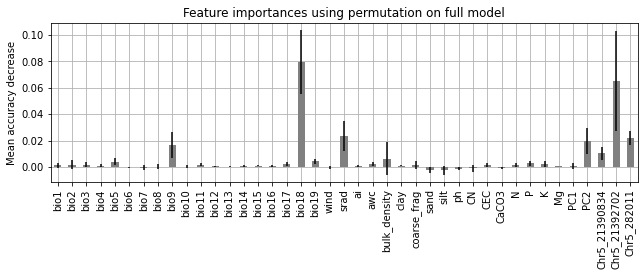

In [411]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [142]:
df2_filtered=df2[['Mg25','bio9','bio18','srad','AWC','Chr5_21390834','Chr5_21392702','Chr5_282011']]
df2_filtered.head()

,Mg25,bio9,bio18,srad,AWC,Chr5_21390834,Chr5_21392702,Chr5_282011
0,4513.790113,18.916666,134,11783.83301,0.081047,0.0,0.0,1.0
1,4444.244161,15.983334,193,11146.58301,0.091235,0.0,0.0,1.0
2,4548.751871,15.983334,193,11146.58301,0.091235,0.0,0.0,1.0
3,4808.545837,5.133333,213,11838.91699,0.102306,0.0,0.0,1.0
4,5189.422620,6.666667,217,12031.58301,0.103813,0.0,0.0,1.0


In [143]:
X=df2_filtered.drop(columns=['Mg25'])
y=df2_filtered['Mg25']

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [145]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[50,100,200]}
forest_model= RandomForestRegressor(random_state = 1)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 6, 'max_leaf_nodes': 9, 'n_estimators': 200}
0.30264819133203286


In [146]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 3))

Mean Absolute Error: 282.27
Mean Squared Error: 127232.74
R-squared scores: 0.346


In [147]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=1, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

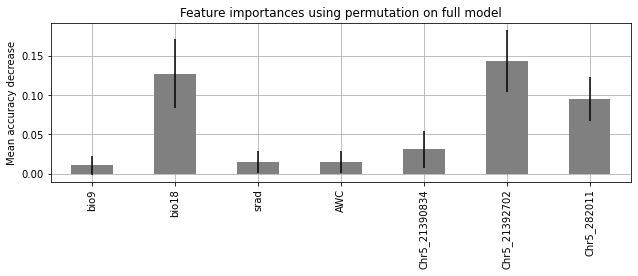

In [148]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [412]:
df2=pd.read_table('Fig1c_test.txt')
df2.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,Mg,PC1,PC2,S470fs,top_peak,splice,N715A,Chr5_21390834,Chr5_21392702,Chr5_282011
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,4513.790113,11.829166,...,38,-0.024919,0.024124,0,0,0,1,0.0,0.0,1.0
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,4444.244161,11.100000,...,31,-0.017065,0.018734,0,0,0,1,0.0,0.0,1.0
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,4548.751871,11.100000,...,31,-0.018403,0.018840,0,0,0,1,0.0,0.0,1.0
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,4808.545837,9.325000,...,29,-0.029610,0.022555,0,0,0,1,0.0,0.0,1.0
4,350,TOU-A1-88,France,46.6667,4.116670,CS77382,leaf,France_leaf,5189.422620,10.720833,...,36,-0.029266,0.026182,0,0,0,1,0.0,0.0,1.0


In [413]:
df2.shape

(677, 54)

In [414]:
df2=df2.dropna()

In [415]:
df2=df2[df2.duplicated(subset=['Country'],keep=False)]

In [416]:
X=df2.drop(columns=['Mg25'])
y=df2['Mg25']

In [417]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0,stratify=X['Country'])

In [418]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A','Chr5_21390834','Chr5_21392702','Chr5_282011'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
619,10.158334,7.583333,34.159161,547.119873,22.9,0.7,22.199999,7.133333,6.216667,16.983334,...,6.203156,11.780995,7.645063,1.362831,1.860576,46.690781,205.509262,37,-0.008169,0.015554
283,10.079166,8.125000,31.988190,661.422241,24.4,-1.0,25.400000,16.783333,3.250000,18.383333,...,5.900896,15.060525,4.649007,38.131313,1.570979,23.699923,141.818512,42,-0.037216,-0.001287
473,12.004167,10.725000,33.939873,775.430847,29.0,-2.6,31.600000,7.700000,20.950001,21.549999,...,6.778843,12.814929,27.501640,72.673447,1.338050,19.887054,249.277084,40,0.002278,0.011588
98,7.820833,6.758333,28.758865,642.680664,21.0,-2.5,23.500000,4.750000,2.666667,15.966666,...,5.713981,14.544075,9.685768,2.897898,2.495770,38.483131,89.823921,36,-0.019560,-0.040287
461,11.250000,9.366667,31.537598,767.673584,27.0,-2.7,29.700001,16.600000,1.733333,20.616667,...,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.020131,-0.015884


In [419]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A','Chr5_21390834','Chr5_21392702','Chr5_282011'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
270,9.950000,7.700000,37.745098,475.461517,21.600000,1.2,20.400000,5.466667,14.300000,16.000000,...,6.318985,10.549542,12.843287,17.212914,3.450265,39.596661,211.670746,34,-0.028628,0.002165
407,12.708333,8.316667,41.792294,433.583557,23.100000,3.2,19.900000,10.566667,18.083334,18.283333,...,5.788593,9.745921,13.185417,0.000000,2.819362,37.183872,268.577087,41,0.009936,0.011404
513,8.375000,9.400000,35.074627,659.853638,23.500000,-3.3,26.799999,14.916667,1.516667,16.633333,...,6.428132,9.122652,12.113892,0.000000,2.160906,40.403454,220.521973,46,-0.034134,0.009626
545,11.633333,11.900000,40.202702,632.427978,29.000000,-0.6,29.600000,7.883333,19.633333,19.816666,...,6.823444,13.519884,6.780015,35.766224,0.961916,13.741580,154.928467,55,0.035880,0.049226
294,8.904166,7.875000,31.882591,643.906616,22.799999,-1.9,24.699999,15.466666,4.733333,17.000000,...,6.799488,9.878675,14.539287,4.578620,1.903177,48.942635,256.557770,47,-0.032175,-0.006864


In [429]:
lr_model= LinearRegression()
lr_model.fit(X_train,y_train)
y_pred=lr_model.predict(X_test)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('R-squared scores:', round(r2, 3))

R-squared scores: 0.251


In [432]:

print(r2_score(y_train.values.ravel(), lr_model.predict(X_train)))

0.2831968027390418


In [434]:
lr_model.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'normalize': False,
 'positive': False}

In [435]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lr_model, X_test, y_test, n_repeats=100, random_state=1, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

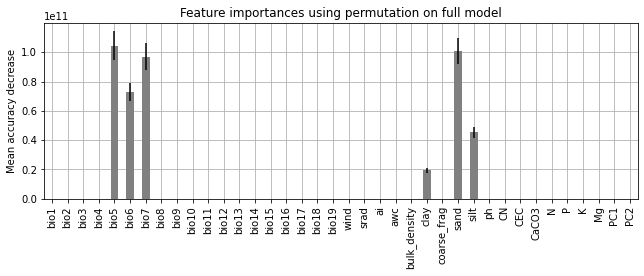

In [436]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [438]:
from sklearn.model_selection import GridSearchCV
parameters ={'fit_intercept': [True, False],}
lr_model= LinearRegression()
lr_model_cv=GridSearchCV(lr_model,parameters,cv=4)
lr_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 5, 'max_leaf_nodes': 8, 'n_estimators': 200}
0.28381614336010075
